In [128]:
import pandas  as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [129]:
X, y = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

In [130]:
df = pd.DataFrame(X,columns=['feature_1','feature_2'])

In [131]:
df

,feature_1,feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [132]:
scale = StandardScaler()
x_scaled = scale.fit_transform(df)

In [133]:
x_scaled

array([[-9.69818350e-01, -1.33993820e+00],
       [ 9.63343617e-01,  8.22475346e-02],
       [ 1.57864695e+00,  1.26351772e-02],
       [-2.46735247e-01,  1.03557927e+00],
       [ 1.45416962e+00,  4.95852224e-02],
       [ 1.40747082e+00,  8.22344111e-03],
       [-7.92177264e-01, -1.28388698e+00],
       [ 1.33697413e+00,  8.26220693e-02],
       [ 1.16849128e+00,  7.41152400e-02],
       [-1.19320161e+00, -1.27260956e+00],
       [ 1.22150712e+00, -1.25922376e-02],
       [-5.14797137e-02,  1.09492794e+00],
       [ 7.12157877e-02,  9.90472440e-01],
       [-1.25480095e-01,  1.27553591e+00],
       [ 1.33940654e+00,  2.78868839e-01],
       [ 1.43619041e+00, -7.51130357e-02],
       [-2.06430378e-01,  1.26334617e+00],
       [-1.25589470e+00, -1.23971291e+00],
       [-1.10416740e+00, -1.17664933e+00],
       [-3.36666506e-01,  1.06025816e+00],
       [ 1.12682035e+00,  1.39235617e-01],
       [-1.71064404e-01,  9.89772412e-01],
       [ 1.37551647e+00,  1.15995990e-01],
       [-9.

In [134]:
inertia = []
k_range = range(1, 11)

In [135]:
for k in k_range:
    Kmeans = KMeans(n_clusters=k,random_state=42)
    Kmeans.fit(x_scaled)
    inertia.append(Kmeans.inertia_)


In [136]:
inertia

[1000.0,
 297.8954141051722,
 11.57548472310498,
 9.752067977356841,
 8.25717527244628,
 6.9175773204167985,
 6.334755391595287,
 5.70417717790143,
 5.060234133532076,
 4.762361898130397]

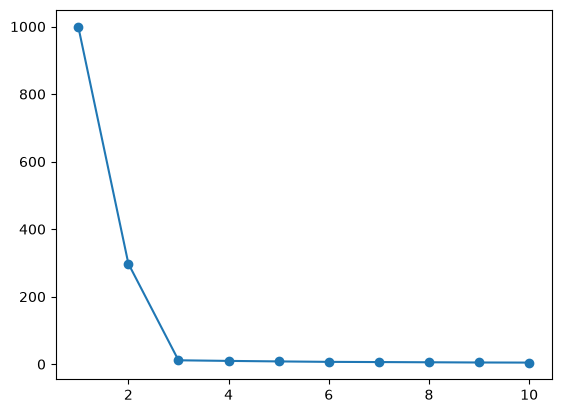

In [137]:
plt.plot(k_range,inertia,marker='o')

In [138]:
Kmeans_final = KMeans(n_clusters=3,random_state=42)


In [139]:
cluster_label = Kmeans_final.fit_predict(x_scaled)

In [140]:
cluster_label

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [141]:
df['cluster'] = cluster_label

<Axes: xlabel='feature_1', ylabel='feature_2'>

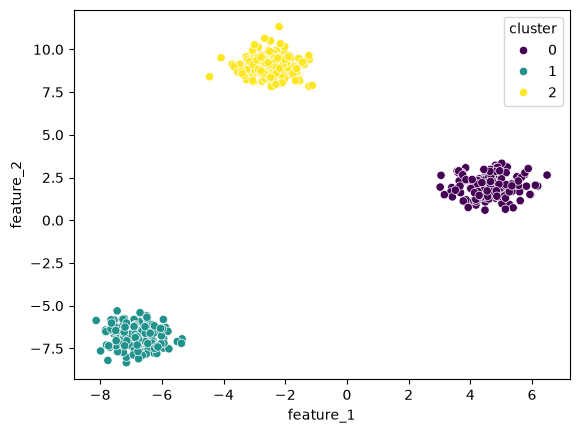

In [142]:
sns.scatterplot(x=df['feature_1'],y=df['feature_2'],hue=df['cluster'],palette='viridis')

                 Disadvantage
1/  we have ti initialise the k value 
2/  outlier wll move the center point
3/  non circular data

than we used DB Scan

In [143]:
from sklearn.datasets import make_moons


In [144]:
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

In [145]:
from sklearn.cluster import KMeans,DBSCAN

In [146]:
df = pd.DataFrame(X,columns=['feature1','feature2'])

In [147]:
df

,feature1,feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [148]:
scale = StandardScaler()


In [149]:
x_scaled = scale.fit_transform(df)

In [150]:
Kmeans = KMeans(n_clusters=2,random_state=42)
Kmeans_label = Kmeans.fit_predict(x_scaled)

In [151]:
df['Kmeans_cluster'] = Kmeans_label

<Axes: xlabel='feature1', ylabel='feature2'>

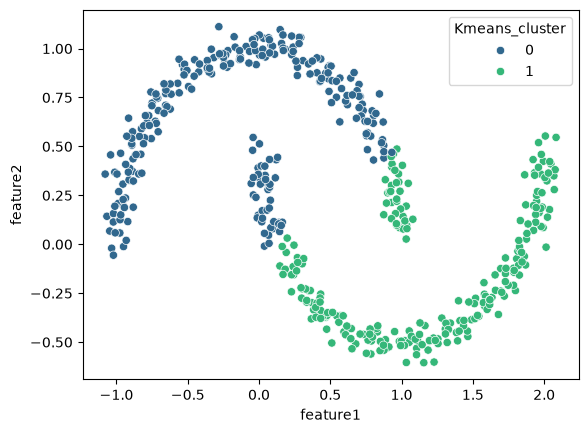

In [152]:
sns.scatterplot(x=df['feature1'],y=df['feature2'],hue=df['Kmeans_cluster'],palette='viridis')

In [153]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_label = dbscan.fit_predict(x_scaled)

In [154]:
df['dbscan_cluster'] = dbscan_label

<Axes: xlabel='feature1', ylabel='feature2'>

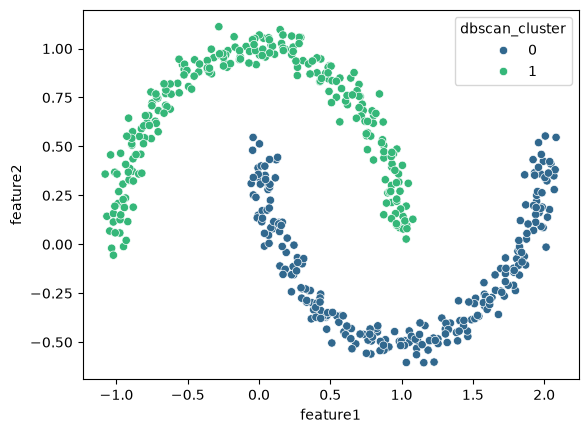

In [155]:
sns.scatterplot(x=df['feature1'],y=df['feature2'],hue=df['dbscan_cluster'],palette='viridis')

(PCA) principle component analysis

In [156]:
import pandas  as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [157]:
X, y = make_blobs(
    n_samples=500,
    centers=3,
    n_features=5,
    cluster_std=1.5,
    random_state=42
)

In [158]:
X

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]], shape=(500, 5))

In [159]:
scale = StandardScaler()
x_scaled = scale.fit_transform(X)

In [160]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

In [161]:
x_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [162]:
df_pca = pd.DataFrame(x_pca,columns=['pca1','pca2'])
df_pca['label'] = y


<Axes: xlabel='pca1', ylabel='pca2'>

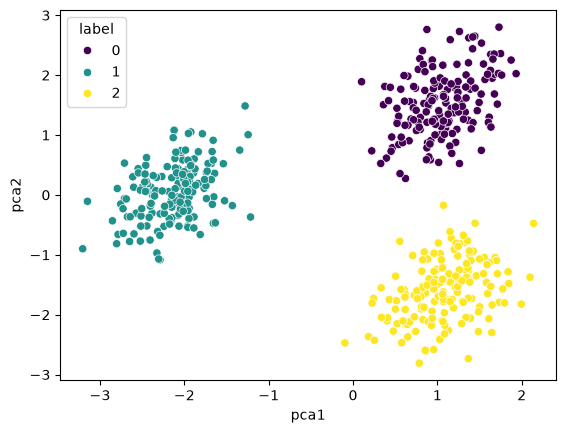

In [165]:
sns.scatterplot(x=df_pca['pca1'],y=df_pca['pca2'],hue=df_pca['label'],palette='viridis')